# Controlled Poisson LDS with force input

Fit condition-specific and pooled Poisson LDS models using standardized binned force as a time-varying dynamics input.

## Imports and configuration

In [1]:
from pathlib import Path
import os
import sys
sys.path.append(os.path.abspath(".."))
from utils.data import load_mc_pacman_data, print_data_structure
import pickle

SCRATCH = Path(os.environ.get("SCRATCH", "/farmshare/user_data/vivek772/stats-305c-data"))
os.environ.setdefault("SCRATCH", str(SCRATCH))
os.environ.setdefault("DATA", str(SCRATCH.parent))
DATA_PATH = SCRATCH / "mc_pacman.pkl"
TMP_DIR = SCRATCH / "tmp"
TMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("TMPDIR", str(TMP_DIR))
os.environ.setdefault("MPLCONFIGDIR", str(TMP_DIR / "matplotlib"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

MODEL_DIR = Path(os.environ.get("POISSON_LDS_MODEL_DIR", "models"))
MODEL_DIR.mkdir(parents=True, exist_ok=True)

import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import HTML, display
from plotly.subplots import make_subplots
from jax import vmap

from dynamax.generalized_gaussian_ssm import GeneralizedGaussianSSM, EKFIntegrals
from dynamax.generalized_gaussian_ssm import conditional_moments_gaussian_smoother as cmgs

BIN_MS = 50
SMOOTH_SIGMA_BINS = 1.0
STATE_DIM = 8
LEARNING_STEPS = 100
LEARNING_RATE = 1e-2
TEST_FRACTION = 0.2
SEED = 7


## Data loading

In [2]:
data = load_mc_pacman_data()
conditions = np.asarray(data["condition"])
force_trials = data["force"]
spike_trials = data["spikes"]


## Controlled Poisson LDS imports

In [3]:
from utils.preprocessing import (
    bin_and_smooth_trials,
    split_condition_trials,
    pooled_split_indices,
    standardize_train_test,
    stack_trials,
)

from utils.poisson_lds import (
    COV_FLOOR,
    RATE_FLOOR,
    PoissonLDSInputParams,
    infer_latents_with_inputs,
    learn_poisson_lds_with_inputs,
    learn_poisson_lds_with_inputs_grouped,
    make_poisson_lds_input_params,
    marginal_log_prob_per_bin_with_inputs,
    poisson_rate,
    predict_expected_counts_with_inputs,
)

from utils.evaluation import mean_feature_variance_explained, variance_explained
from utils.lds_cache import (
    lds_metadata as make_lds_metadata,
    lds_path as make_lds_path,
    load_or_fit_lds,
)


## Shape and evaluation helpers

In [4]:
def validate_y_u_trials(y_trials, u_trials, *, label):
    if len(y_trials) != len(u_trials):
        raise ValueError(f"{label}: y and u trial lists have different lengths")
    if not y_trials:
        raise ValueError(f"{label}: at least one trial is required")
    for i, (y, u) in enumerate(zip(y_trials, u_trials)):
        y = np.asarray(y)
        u = np.asarray(u)
        if y.ndim != 2 or u.ndim != 2:
            raise ValueError(f"{label} trial {i}: y and u must both be 2D")
        if y.shape[0] != u.shape[0]:
            raise ValueError(f"{label} trial {i}: y and u lengths differ: {y.shape[0]} vs {u.shape[0]}")
        if u.shape[-1] != 1:
            raise ValueError(f"{label} trial {i}: expected one force input, got shape {u.shape}")


def zero_like_trials(u_trials):
    return [np.zeros_like(np.asarray(u, dtype=np.float64)) for u in u_trials]


def concatenate_trials(trials):
    return np.concatenate([np.asarray(x, dtype=float) for x in trials], axis=0)


def validate_expected_counts(expected_counts, y_trials, *, label):
    for i, (expected, y) in enumerate(zip(expected_counts, y_trials)):
        expected = np.asarray(expected)
        y = np.asarray(y)
        if expected.shape != y.shape:
            raise ValueError(f"{label} trial {i}: predicted shape {expected.shape} != observed shape {y.shape}")
        if not np.all(np.isfinite(expected)) or np.any(expected < 0):
            raise FloatingPointError(f"{label} trial {i}: invalid predicted counts")
    return expected_counts


## Model fitting functions

In [5]:
def fit_condition_input_lds(
    cond,
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    test_fraction=TEST_FRACTION,
    verbose=False,
):
    train_idx, test_idx = split_condition_trials(conditions, cond, test_fraction, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, bin_ms, 0, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, bin_ms, 0, "spikes")
    force_train = bin_and_smooth_trials(train_force, bin_ms, smooth_sigma_bins, "force")
    force_test = bin_and_smooth_trials(test_force, bin_ms, smooth_sigma_bins, "force")
    u_train, u_test, force_mean, force_std = standardize_train_test(force_train, force_test)

    validate_y_u_trials(y_train, u_train, label=f"condition {cond} train")
    validate_y_u_trials(y_test, u_test, label=f"condition {cond} test")

    y_train_stack = stack_trials(y_train)
    u_train_stack = stack_trials(u_train)
    model = GeneralizedGaussianSSM(
        state_dim=state_dim,
        emission_dim=y_train_stack.shape[-1],
        input_dim=u_train_stack.shape[-1],
    )
    key = jr.PRNGKey(seed + 1000 + int(cond))
    trainable_params, params, lls = learn_poisson_lds_with_inputs(
        y_train_stack,
        u_train_stack,
        state_dim=state_dim,
        key=key,
        learning_steps=learning_steps,
        learning_rate=learning_rate,
        verbose=verbose,
    )

    return {
        "condition": int(cond),
        "model": model,
        "params": params,
        "trainable_params": trainable_params,
        "training_log_likelihoods": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "y_train": y_train,
        "y_test": y_test,
        "u_train": u_train,
        "u_test": u_test,
        "force_train": force_train,
        "force_test": force_test,
        "force_mean": np.asarray(force_mean, dtype=float),
        "force_std": np.asarray(force_std, dtype=float),
    }


def fit_pooled_input_lds(
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    test_fraction=TEST_FRACTION,
    verbose=False,
):
    train_idx, test_idx = pooled_split_indices(conditions, test_fraction, seed)
    train_spikes = [spike_trials[i] for i in train_idx]
    test_spikes = [spike_trials[i] for i in test_idx]
    train_force = [force_trials[i] for i in train_idx]
    test_force = [force_trials[i] for i in test_idx]

    y_train = bin_and_smooth_trials(train_spikes, bin_ms, 0, "spikes")
    y_test = bin_and_smooth_trials(test_spikes, bin_ms, 0, "spikes")
    force_train = bin_and_smooth_trials(train_force, bin_ms, smooth_sigma_bins, "force")
    force_test = bin_and_smooth_trials(test_force, bin_ms, smooth_sigma_bins, "force")
    u_train, u_test, force_mean, force_std = standardize_train_test(force_train, force_test)

    validate_y_u_trials(y_train, u_train, label="pooled train")
    validate_y_u_trials(y_test, u_test, label="pooled test")

    model = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=y_train[0].shape[-1], input_dim=u_train[0].shape[-1])
    key = jr.PRNGKey(seed + 2000)
    trainable_params, params, lls = learn_poisson_lds_with_inputs_grouped(
        y_train,
        u_train,
        state_dim=state_dim,
        key=key,
        learning_steps=learning_steps,
        learning_rate=learning_rate,
        verbose=verbose,
    )

    return {
        "condition": "pooled",
        "model": model,
        "params": params,
        "trainable_params": trainable_params,
        "training_log_likelihoods_per_bin": lls,
        "train_idx": train_idx,
        "test_idx": test_idx,
        "condition_train": np.asarray(conditions[train_idx], dtype=int),
        "condition_test": np.asarray(conditions[test_idx], dtype=int),
        "y_train": y_train,
        "y_test": y_test,
        "u_train": u_train,
        "u_test": u_test,
        "force_train": force_train,
        "force_test": force_test,
        "force_mean": np.asarray(force_mean, dtype=float),
        "force_std": np.asarray(force_std, dtype=float),
    }


## Cache helpers

In [6]:
MODEL_CACHE_VERSION = "poisson_lds_force_input_v1"


def input_trainable_params_to_arrays(trainable_params):
    return {name: np.asarray(getattr(trainable_params, name)) for name in trainable_params._fields}


def input_fit_payload_for_pickle(fit):
    payload = dict(fit)
    payload.pop("params", None)
    payload.pop("model", None)
    for key in list(payload):
        if key.startswith("latent_") or key.startswith("expected_"):
            payload.pop(key, None)
    payload["trainable_params"] = input_trainable_params_to_arrays(payload["trainable_params"])
    return payload


def restore_input_fit_from_pickle(payload):
    fit = dict(payload)
    if isinstance(fit["trainable_params"], dict):
        fit["trainable_params"] = PoissonLDSInputParams(
            **{name: jnp.asarray(fit["trainable_params"][name]) for name in PoissonLDSInputParams._fields}
        )
    trainable_params = fit["trainable_params"]
    state_dim = int(trainable_params.A.shape[0])
    emission_dim = int(trainable_params.C.shape[0])
    input_dim = int(trainable_params.B.shape[1])
    fit["params"] = make_poisson_lds_input_params(trainable_params)
    fit["model"] = GeneralizedGaussianSSM(state_dim=state_dim, emission_dim=emission_dim, input_dim=input_dim)
    return fit


def lds_metadata(
    kind,
    *,
    learning_steps,
    state_dim,
    seed,
    bin_ms,
    smooth_sigma_bins,
    learning_rate,
    rate_floor,
    cov_floor,
    test_fraction,
    data_path,
    emission_distribution,
    input_dim=1,
    condition=None,
):
    emission_distribution = str(emission_distribution).lower()
    if emission_distribution != "poisson":
        raise ValueError(f"unsupported emission distribution: {emission_distribution}")
    return make_lds_metadata(
        MODEL_CACHE_VERSION,
        kind,
        emission_distribution,
        data_path,
        condition=condition,
        bin_ms=int(bin_ms),
        smooth_sigma_bins=float(smooth_sigma_bins),
        state_dim=int(state_dim),
        input_dim=int(input_dim),
        learning_steps=int(learning_steps),
        learning_rate=float(learning_rate),
        rate_floor=float(rate_floor),
        cov_floor=float(cov_floor),
        test_fraction=float(test_fraction),
        seed=int(seed),
    )


def lds_path(kind, metadata):
    return make_lds_path(MODEL_DIR, kind, metadata)


def load_or_fit_condition_input_lds(
    cond,
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    rate_floor=RATE_FLOOR,
    cov_floor=COV_FLOOR,
    test_fraction=TEST_FRACTION,
    data_path=DATA_PATH,
    emission_distribution="poisson",
    verbose=False,
):
    metadata = lds_metadata(
        "condition_input_lds",
        learning_steps=learning_steps,
        state_dim=state_dim,
        seed=seed,
        bin_ms=bin_ms,
        smooth_sigma_bins=smooth_sigma_bins,
        learning_rate=learning_rate,
        rate_floor=rate_floor,
        cov_floor=cov_floor,
        test_fraction=test_fraction,
        data_path=data_path,
        emission_distribution=emission_distribution,
        input_dim=1,
        condition=cond,
    )
    path = lds_path("condition_input_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_condition_input_lds(
            cond=int(cond),
            learning_steps=learning_steps,
            state_dim=state_dim,
            seed=seed,
            bin_ms=bin_ms,
            smooth_sigma_bins=smooth_sigma_bins,
            learning_rate=learning_rate,
            test_fraction=test_fraction,
            verbose=verbose,
        ),
        input_fit_payload_for_pickle,
        restore_input_fit_from_pickle,
    )


def load_or_fit_pooled_input_lds(
    learning_steps=LEARNING_STEPS,
    state_dim=STATE_DIM,
    seed=SEED,
    bin_ms=BIN_MS,
    smooth_sigma_bins=SMOOTH_SIGMA_BINS,
    learning_rate=LEARNING_RATE,
    rate_floor=RATE_FLOOR,
    cov_floor=COV_FLOOR,
    test_fraction=TEST_FRACTION,
    data_path=DATA_PATH,
    emission_distribution="poisson",
    verbose=False,
):
    metadata = lds_metadata(
        "pooled_input_lds",
        learning_steps=learning_steps,
        state_dim=state_dim,
        seed=seed,
        bin_ms=bin_ms,
        smooth_sigma_bins=smooth_sigma_bins,
        learning_rate=learning_rate,
        rate_floor=rate_floor,
        cov_floor=cov_floor,
        test_fraction=test_fraction,
        data_path=data_path,
        emission_distribution=emission_distribution,
        input_dim=1,
    )
    path = lds_path("pooled_input_lds", metadata)
    return load_or_fit_lds(
        path,
        metadata,
        lambda: fit_pooled_input_lds(
            learning_steps=learning_steps,
            state_dim=state_dim,
            seed=seed,
            bin_ms=bin_ms,
            smooth_sigma_bins=smooth_sigma_bins,
            learning_rate=learning_rate,
            test_fraction=test_fraction,
            verbose=verbose,
        ),
        input_fit_payload_for_pickle,
        restore_input_fit_from_pickle,
    )


## Input-aware evaluation

In [7]:
def input_trials_for_split(fit, split, *, zero_inputs=False):
    u_trials = fit[f"u_{split}"]
    return zero_like_trials(u_trials) if zero_inputs else u_trials


def predict_input_counts_for_split(fit, split, *, zero_inputs=False):
    y_trials = fit[f"y_{split}"]
    u_trials = input_trials_for_split(fit, split, zero_inputs=zero_inputs)
    expected = predict_expected_counts_with_inputs(fit["params"], fit["trainable_params"], y_trials, u_trials)
    label = f"{fit['condition']} {split} {'zero_u' if zero_inputs else 'true_u'}"
    return validate_expected_counts(expected, y_trials, label=label)


def input_log_prob_per_bin(fit, split, *, zero_inputs=False):
    return marginal_log_prob_per_bin_with_inputs(
        fit["params"],
        fit[f"y_{split}"],
        input_trials_for_split(fit, split, zero_inputs=zero_inputs),
    )


def spike_reconstruction_metrics(fit, split, *, zero_inputs=False):
    expected = predict_input_counts_for_split(fit, split, zero_inputs=zero_inputs)
    y_true = concatenate_trials(fit[f"y_{split}"])
    y_hat = concatenate_trials(expected)
    mean_neuron_ve, n_valid = mean_feature_variance_explained(y_true, y_hat)
    suffix = "zero_u" if zero_inputs else "true_u"
    return {
        f"{split}_spike_var_explained_{suffix}": float(variance_explained(y_true, y_hat)),
        f"{split}_spike_var_explained_mean_neuron_{suffix}": mean_neuron_ve,
        f"{split}_spike_var_explained_n_neurons_{suffix}": n_valid,
    }


def training_trace(fit):
    key = "training_log_likelihoods_per_bin" if "training_log_likelihoods_per_bin" in fit else "training_log_likelihoods"
    trace = np.asarray(fit[key], dtype=float)
    if trace.size == 0 or not np.all(np.isfinite(trace)):
        raise ValueError(f"{fit['condition']}: invalid training trace")
    return key, trace


def summarize_input_fit(fit):
    trace_key, trace = training_trace(fit)
    summary = {
        "condition": fit["condition"],
        "n_train": len(fit["train_idx"]),
        "n_test": len(fit["test_idx"]),
        "n_train_bins_total": int(sum(y.shape[0] for y in fit["y_train"])),
        "n_test_bins_total": int(sum(y.shape[0] for y in fit["y_test"])),
        "input_dim": int(fit["u_train"][0].shape[-1]),
        "training_trace_key": trace_key,
        "final_training_trace": float(trace[-1]),
        "train_ll_per_bin_true_u": input_log_prob_per_bin(fit, "train", zero_inputs=False),
        "test_ll_per_bin_true_u": input_log_prob_per_bin(fit, "test", zero_inputs=False),
        "test_ll_per_bin_zero_u": input_log_prob_per_bin(fit, "test", zero_inputs=True),
    }
    summary.update(spike_reconstruction_metrics(fit, "train", zero_inputs=False))
    summary.update(spike_reconstruction_metrics(fit, "test", zero_inputs=False))
    summary.update(spike_reconstruction_metrics(fit, "test", zero_inputs=True))
    return summary


def assert_finite_summary(summary):
    bad = []
    for key, value in summary.items():
        if isinstance(value, (int, float, np.integer, np.floating)) and not np.isfinite(value):
            bad.append((key, value))
    if bad:
        raise FloatingPointError(f"non-finite summary values: {bad}")
    return summary


def summarize_and_check_input_fit(fit):
    return assert_finite_summary(summarize_input_fit(fit))


## Pooled condition summaries

In [8]:
def pooled_input_spike_variance_by_condition(pooled_fit, split, *, zero_inputs=False):
    predictions = predict_input_counts_for_split(pooled_fit, split, zero_inputs=zero_inputs)
    split_conditions = np.asarray(pooled_fit[f"condition_{split}"], dtype=int)
    input_label = "zero_u" if zero_inputs else "true_u"
    rows = []
    for cond in sorted(np.unique(split_conditions)):
        mask = split_conditions == cond
        y_true = concatenate_trials([y for y, keep in zip(pooled_fit[f"y_{split}"], mask) if keep])
        y_hat = concatenate_trials([y for y, keep in zip(predictions, mask) if keep])
        mean_neuron_ve, n_valid = mean_feature_variance_explained(y_true, y_hat)
        rows.append(
            {
                "condition": int(cond),
                "split": split,
                "input": input_label,
                "n_trials": int(mask.sum()),
                "n_bins_total": int(y_true.shape[0]),
                "spike_var_explained": float(variance_explained(y_true, y_hat)),
                "spike_var_explained_mean_neuron": mean_neuron_ve,
                "spike_var_explained_n_neurons": n_valid,
            }
        )
    return pd.DataFrame(rows)


def pooled_input_summary_tables(pooled_fit):
    pooled_overall = pd.DataFrame([summarize_and_check_input_fit(pooled_fit)])
    pooled_by_condition = pd.concat(
        [
            pooled_input_spike_variance_by_condition(pooled_fit, "train", zero_inputs=False),
            pooled_input_spike_variance_by_condition(pooled_fit, "test", zero_inputs=False),
            pooled_input_spike_variance_by_condition(pooled_fit, "test", zero_inputs=True),
        ],
        ignore_index=True,
    )
    return pooled_overall, pooled_by_condition


## Smoke fit

In [10]:
smoke_fit = load_or_fit_condition_input_lds(cond=1, learning_steps=5, state_dim=STATE_DIM, seed=SEED, verbose=False)
smoke_summary = summarize_and_check_input_fit(smoke_fit)
pd.DataFrame([smoke_summary])


loading model parameters models/condition_input_lds_poisson_cond1_bin50_state18_steps5_seed7.pkl


,condition,n_train,n_test,n_train_bins_total,n_test_bins_total,input_dim,training_trace_key,final_training_trace,train_ll_per_bin_true_u,test_ll_per_bin_true_u,test_ll_per_bin_zero_u,train_spike_var_explained_true_u,train_spike_var_explained_mean_neuron_true_u,train_spike_var_explained_n_neurons_true_u,test_spike_var_explained_true_u,test_spike_var_explained_mean_neuron_true_u,test_spike_var_explained_n_neurons_true_u,test_spike_var_explained_zero_u,test_spike_var_explained_mean_neuron_zero_u,test_spike_var_explained_n_neurons_zero_u
0,1,30,8,3600,960,1,training_log_likelihoods,-7932.917117,-65.87161,-66.276788,-66.289833,0.10135,0.071274,126,0.073708,0.050253,123,0.073965,0.050303,123


## Pooled smoke fit

In [11]:
pooled_smoke_fit = load_or_fit_pooled_input_lds(learning_steps=5, state_dim=STATE_DIM, seed=SEED, verbose=False)
pooled_smoke_summary = summarize_and_check_input_fit(pooled_smoke_fit)
pd.DataFrame([pooled_smoke_summary])


loading model parameters models/pooled_input_lds_poisson_bin50_state18_steps5_seed7.pkl


,condition,n_train,n_test,n_train_bins_total,n_test_bins_total,input_dim,training_trace_key,final_training_trace,train_ll_per_bin_true_u,test_ll_per_bin_true_u,test_ll_per_bin_zero_u,train_spike_var_explained_true_u,train_spike_var_explained_mean_neuron_true_u,train_spike_var_explained_n_neurons_true_u,test_spike_var_explained_true_u,test_spike_var_explained_mean_neuron_true_u,test_spike_var_explained_n_neurons_true_u,test_spike_var_explained_zero_u,test_spike_var_explained_mean_neuron_zero_u,test_spike_var_explained_n_neurons_zero_u
0,pooled,289,73,24581,6222,1,training_log_likelihoods_per_bin,-83.032488,-83.482512,-84.005172,-84.029781,0.175278,0.105975,128,0.172586,0.105797,128,0.172294,0.10547,128


## Full per-condition run

In [9]:
fits = {}
rows = []
for cond in sorted(np.unique(conditions)):
    fit = load_or_fit_condition_input_lds(
        cond=int(cond),
        learning_steps=LEARNING_STEPS,
        state_dim=STATE_DIM,
        seed=SEED,
        verbose=False,
    )
    fits[int(cond)] = fit
    rows.append(summarize_and_check_input_fit(fit))

results = pd.DataFrame(rows).sort_values("condition").reset_index(drop=True)
results


saved model parameters models/condition_input_lds_poisson_cond1_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond2_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond3_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond4_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond5_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond6_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond7_bin50_state8_steps100_seed7.pkl
saved model parameters models/condition_input_lds_poisson_cond8_bin50_state8_steps100_seed7.pkl


,condition,n_train,n_test,n_train_bins_total,n_test_bins_total,input_dim,training_trace_key,final_training_trace,train_ll_per_bin_true_u,test_ll_per_bin_true_u,test_ll_per_bin_zero_u,train_spike_var_explained_true_u,train_spike_var_explained_mean_neuron_true_u,train_spike_var_explained_n_neurons_true_u,test_spike_var_explained_true_u,test_spike_var_explained_mean_neuron_true_u,test_spike_var_explained_n_neurons_true_u,test_spike_var_explained_zero_u,test_spike_var_explained_mean_neuron_zero_u,test_spike_var_explained_n_neurons_zero_u
0,1,30,8,3600,960,1,training_log_likelihoods,-7696.915166,-64.139046,-65.006522,-65.206984,0.158167,0.125980,126,0.126077,0.087892,123,0.125268,0.088766,123
1,2,28,7,3360,840,1,training_log_likelihoods,-8258.552782,-68.816694,-68.071642,-68.326179,0.281849,0.163571,126,0.249265,0.120241,126,0.247413,0.120527,126
2,3,30,8,1350,360,1,training_log_likelihoods,-3135.469513,-69.668567,-73.523784,-73.797629,0.283791,0.191015,126,0.222803,0.150958,125,0.222943,0.149230,125
3,4,30,7,1350,315,1,training_log_likelihoods,-3191.403210,-70.911356,-74.043074,-74.893582,0.386200,0.195461,128,0.324341,0.142370,122,0.322541,0.141455,122
4,5,29,7,3480,840,1,training_log_likelihoods,-8795.789317,-73.293996,-74.098268,-74.304270,0.278832,0.171603,128,0.254749,0.141431,127,0.254774,0.141199,127
5,6,34,9,2720,720,1,training_log_likelihoods,-6595.441028,-82.437327,-84.855643,-85.569754,0.342111,0.204186,128,0.319475,0.169694,127,0.316592,0.168720,127
6,7,49,12,3234,792,1,training_log_likelihoods,-5667.937093,-85.862780,-87.014513,-89.658095,0.325198,0.199082,128,0.307833,0.178984,127,0.285222,0.169474,127
7,8,59,15,5487,1395,1,training_log_likelihoods,-7789.948226,-83.753264,-85.348545,-86.230278,0.324396,0.191316,128,0.298030,0.174263,128,0.295723,0.171560,128


## Pooled all-condition fit

In [10]:
pooled_fit = load_or_fit_pooled_input_lds(learning_steps=LEARNING_STEPS, state_dim=STATE_DIM, seed=SEED, verbose=False)
pooled_overall, pooled_by_condition = pooled_input_summary_tables(pooled_fit)
pooled_overall


saved model parameters models/pooled_input_lds_poisson_bin50_state8_steps100_seed7.pkl


,condition,n_train,n_test,n_train_bins_total,n_test_bins_total,input_dim,training_trace_key,final_training_trace,train_ll_per_bin_true_u,test_ll_per_bin_true_u,test_ll_per_bin_zero_u,train_spike_var_explained_true_u,train_spike_var_explained_mean_neuron_true_u,train_spike_var_explained_n_neurons_true_u,test_spike_var_explained_true_u,test_spike_var_explained_mean_neuron_true_u,test_spike_var_explained_n_neurons_true_u,test_spike_var_explained_zero_u,test_spike_var_explained_mean_neuron_zero_u,test_spike_var_explained_n_neurons_zero_u
0,pooled,289,73,24581,6222,1,training_log_likelihoods_per_bin,-78.917443,-79.831904,-80.322529,-80.709658,0.279571,0.180541,128,0.276503,0.181123,128,0.273,0.179078,128


In [11]:
pooled_by_condition


,condition,split,input,n_trials,n_bins_total,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons
0,1,train,true_u,30,3600,0.128094,0.082693,126
1,2,train,true_u,28,3360,0.225242,0.115659,126
2,3,train,true_u,30,1350,0.200774,0.090243,126
3,4,train,true_u,30,1350,0.301483,0.113781,128
4,5,train,true_u,29,3480,0.238442,0.134172,128
5,6,train,true_u,34,2720,0.264713,0.145479,128
6,7,train,true_u,49,3234,0.265407,0.136833,128
7,8,train,true_u,59,5487,0.287949,0.154231,128
8,1,test,true_u,8,960,0.116849,0.073524,123
9,2,test,true_u,7,840,0.206431,0.092967,126


## Results summary plots

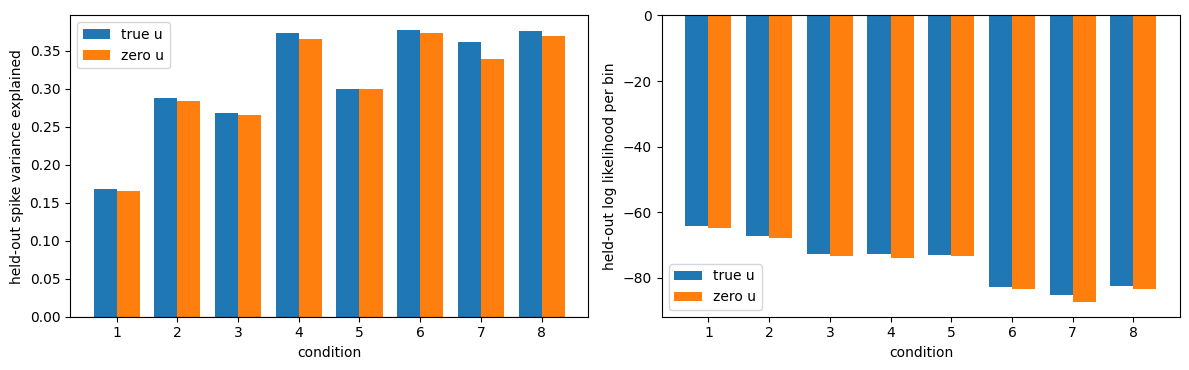

,condition,n_train,n_test,n_train_bins_total,n_test_bins_total,input_dim,training_trace_key,final_training_trace,train_ll_per_bin_true_u,test_ll_per_bin_true_u,test_ll_per_bin_zero_u,train_spike_var_explained_true_u,train_spike_var_explained_mean_neuron_true_u,train_spike_var_explained_n_neurons_true_u,test_spike_var_explained_true_u,test_spike_var_explained_mean_neuron_true_u,test_spike_var_explained_n_neurons_true_u,test_spike_var_explained_zero_u,test_spike_var_explained_mean_neuron_zero_u,test_spike_var_explained_n_neurons_zero_u
0,1,30,8,3600,960,1,training_log_likelihoods,-7553.872885,-62.953117,-64.399653,-64.714908,0.212624,0.180920,126,0.167732,0.129711,123,0.166172,0.127983,123
1,2,28,7,3360,840,1,training_log_likelihoods,-8072.771913,-67.268987,-67.435774,-67.876355,0.341758,0.220650,126,0.288417,0.152993,126,0.283390,0.153182,126
2,3,30,8,1350,360,1,training_log_likelihoods,-3050.630132,-67.748599,-72.835327,-73.457004,0.349394,0.258145,126,0.267866,0.183616,125,0.265534,0.178219,125
3,4,30,7,1350,315,1,training_log_likelihoods,-3092.197578,-68.723287,-72.835143,-73.951798,0.444079,0.255306,128,0.373129,0.176897,122,0.365616,0.168476,122
4,5,29,7,3480,840,1,training_log_likelihoods,-8592.862016,-71.602282,-73.219355,-73.492238,0.334069,0.229210,128,0.299776,0.178330,127,0.299317,0.176697,127
5,6,34,9,2720,720,1,training_log_likelihoods,-6407.459905,-80.087990,-82.861034,-83.389190,0.405090,0.263595,128,0.377733,0.214388,127,0.373277,0.214100,127
6,7,49,12,3234,792,1,training_log_likelihoods,-5515.514516,-83.553195,-85.329281,-87.566513,0.387867,0.259961,128,0.361649,0.227728,127,0.339928,0.216410,127
7,8,59,15,5487,1395,1,training_log_likelihoods,-7512.571055,-80.768903,-82.612961,-83.570410,0.399699,0.265641,128,0.375842,0.235085,128,0.370133,0.231451,128


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
width = 0.38
conds = results["condition"].to_numpy(dtype=float)
axes[0].bar(conds - width / 2, results["test_spike_var_explained_true_u"], width=width, label="true u")
axes[0].bar(conds + width / 2, results["test_spike_var_explained_zero_u"], width=width, label="zero u")
axes[0].axhline(0, color="black", lw=0.8)
axes[0].set_xlabel("condition")
axes[0].set_ylabel("held-out spike variance explained")
axes[0].legend()

axes[1].bar(conds - width / 2, results["test_ll_per_bin_true_u"], width=width, label="true u")
axes[1].bar(conds + width / 2, results["test_ll_per_bin_zero_u"], width=width, label="zero u")
axes[1].set_xlabel("condition")
axes[1].set_ylabel("held-out log likelihood per bin")
axes[1].legend()
plt.tight_layout()
plt.show()

results


In [16]:
with open("../eda/saved_models/condition_lds_gaussian_cond1_bin50_state8_iters100_seed7.pkl", 'rb') as pkl:
    out = pickle.load(pkl)

print(out.keys())
print(out['fit'].keys())
print(out['fit']['condition'])

dict_keys(['metadata', 'fit'])
dict_keys(['condition', 'params', 'em_log_likelihoods', 'train_idx', 'test_idx', 'y_train', 'y_test', 'force_train', 'force_test', 'obs_mean', 'obs_std'])
1


## Pooled summary plots

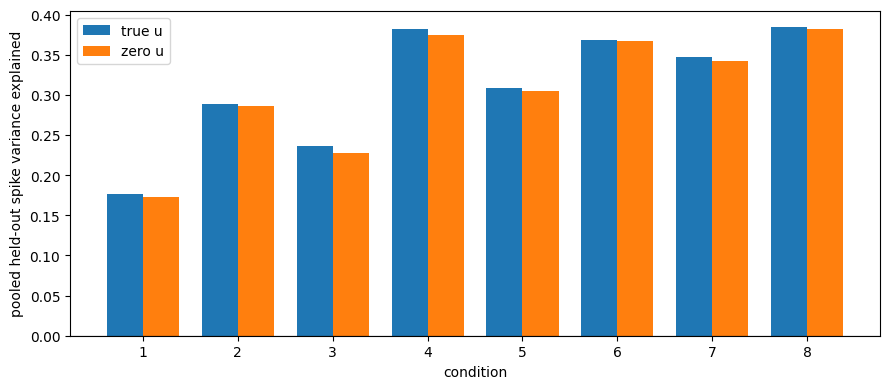

,condition,split,input,n_trials,n_bins_total,spike_var_explained,spike_var_explained_mean_neuron,spike_var_explained_n_neurons
0,1,train,true_u,30,3600,0.197525,0.137856,126
1,2,train,true_u,28,3360,0.313668,0.177385,126
2,3,train,true_u,30,1350,0.276558,0.159316,126
3,4,train,true_u,30,1350,0.401065,0.182671,128
4,5,train,true_u,29,3480,0.317480,0.195098,128
5,6,train,true_u,34,2720,0.377487,0.228951,128
6,7,train,true_u,49,3234,0.358375,0.214640,128
7,8,train,true_u,59,5487,0.386240,0.236853,128
8,1,test,true_u,8,960,0.176169,0.124497,123
9,2,test,true_u,7,840,0.289189,0.153757,126


In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
width = 0.38
true_df = pooled_by_condition.query("split == 'test' and input == 'true_u'").sort_values("condition")
zero_df = pooled_by_condition.query("split == 'test' and input == 'zero_u'").sort_values("condition")
conds = true_df["condition"].to_numpy(dtype=float)
ax.bar(conds - width / 2, true_df["spike_var_explained"], width=width, label="true u")
ax.bar(conds + width / 2, zero_df["spike_var_explained"], width=width, label="zero u")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("condition")
ax.set_ylabel("pooled held-out spike variance explained")
ax.legend()
plt.tight_layout()
plt.show()

pooled_by_condition


## Learning convergence

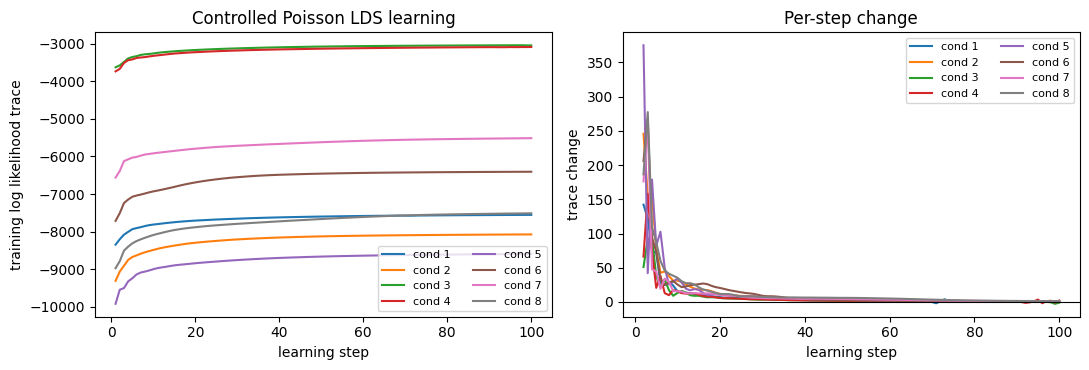

In [18]:
def plot_learning_convergence(fits):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
    for cond in sorted(fits):
        _, trace = training_trace(fits[cond])
        steps = np.arange(1, trace.size + 1)
        axes[0].plot(steps, trace, label=f"cond {cond}")
        if trace.size > 1:
            axes[1].plot(steps[1:], np.diff(trace), label=f"cond {cond}")

    axes[0].set_xlabel("learning step")
    axes[0].set_ylabel("training log likelihood trace")
    axes[0].set_title("Controlled Poisson LDS learning")
    axes[0].legend(ncol=2, fontsize=8)

    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xlabel("learning step")
    axes[1].set_ylabel("trace change")
    axes[1].set_title("Per-step change")
    axes[1].legend(ncol=2, fontsize=8)
    plt.tight_layout()
    return fig, axes


plot_learning_convergence(fits)
plt.show()


## Interactive neural dynamics and prediction plots

In [19]:
def _split_trials(fit, split):
    if split not in {"train", "test"}:
        raise ValueError("split must be 'train' or 'test'")
    return fit[f"y_{split}"], fit[f"force_{split}"], fit[f"u_{split}"]


def _time_ms(n_bins):
    return np.arange(n_bins) * BIN_MS


def _trial_data(fit, split, trial_number):
    y_trials, force_trials_for_split, u_trials = _split_trials(fit, split)
    if trial_number < 0 or trial_number >= len(y_trials):
        raise ValueError(f"trial_number must be in [0, {len(y_trials) - 1}] for condition {fit['condition']} {split}")

    y = np.asarray(y_trials[trial_number], dtype=float)
    force = np.asarray(force_trials_for_split[trial_number], dtype=float).reshape(y.shape[0], -1)
    u = np.asarray(u_trials[trial_number], dtype=float).reshape(y.shape[0], -1)
    if force.shape[0] != y.shape[0] or u.shape[0] != y.shape[0]:
        raise ValueError("force, input, and spike counts have different time lengths")
    return y, force[:, 0], u


def _latent_and_expected_counts(fit, y, u, *, zero_inputs=False):
    u_eval = np.zeros_like(u) if zero_inputs else u
    posterior = cmgs(fit["params"], EKFIntegrals(), jnp.asarray(y), inputs=jnp.asarray(u_eval))
    z = np.asarray(posterior.smoothed_means)
    expected = np.asarray(vmap(lambda state: poisson_rate(fit["trainable_params"], state))(jnp.asarray(z)))
    validate_expected_counts([expected], [y], label=f"{fit['condition']} {'zero_u' if zero_inputs else 'true_u'}")
    return z, expected


def _population_count(y):
    return np.asarray(y, dtype=float).sum(axis=1)


def _averaged_condition_data(fit, split="test"):
    y_trials, force_trials_for_split, u_trials = _split_trials(fit, split)
    latents = []
    observed_counts = []
    expected_counts = []
    expected_counts_zero = []
    forces = []

    for y, force, u in zip(y_trials, force_trials_for_split, u_trials):
        y = np.asarray(y, dtype=float)
        force = np.asarray(force, dtype=float).reshape(y.shape[0], -1)[:, 0]
        u = np.asarray(u, dtype=float).reshape(y.shape[0], -1)
        z, expected = _latent_and_expected_counts(fit, y, u, zero_inputs=False)
        _, expected_zero = _latent_and_expected_counts(fit, y, u, zero_inputs=True)
        latents.append(z)
        observed_counts.append(_population_count(y))
        expected_counts.append(_population_count(expected))
        expected_counts_zero.append(_population_count(expected_zero))
        forces.append(force)

    return {
        "latent": np.mean(np.stack(latents), axis=0),
        "observed_count": np.mean(np.stack(observed_counts), axis=0),
        "expected_count": np.mean(np.stack(expected_counts), axis=0),
        "expected_count_zero": np.mean(np.stack(expected_counts_zero), axis=0),
        "force": np.mean(np.stack(forces), axis=0),
    }


def _condition_options(fits):
    return [(f"condition {cond}", cond) for cond in sorted(fits)]


def _global_trial_index(fit, split, trial_number):
    idx = np.asarray(fit.get(f"{split}_idx", np.arange(len(fit[f"y_{split}"]))))
    return int(idx[trial_number])


def _trial_title(condition, split, trial_number, global_trial):
    return f"Condition {condition} {split} trial {trial_number} (dataset idx {global_trial})"


def _trial_options(fit, split):
    return [(f"trial {i} (dataset idx {_global_trial_index(fit, split, i)})", i) for i in range(len(fit[f"y_{split}"]))]


def _condition_trial_controls(fits, split):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")
    trial = widgets.Dropdown(options=_trial_options(fits[condition.value], split), description="trial")

    def update_trials(change):
        options = _trial_options(fits[change["new"]], split)
        with trial.hold_trait_notifications():
            trial.options = options
            trial.value = options[0][1]

    condition.observe(update_trials, names="value")
    return condition, trial


def _show_plot(fig):
    fig.update_layout(template="plotly_white", hovermode="x unified", height=620)
    display(HTML(fig.to_html(full_html=False, include_plotlyjs="cdn")))


In [20]:
def plot_single_trial_latents_and_force(fits, split="test"):
    condition, trial = _condition_trial_controls(fits, split)

    def render(condition, trial):
        fit = fits[condition]
        y, force, u = _trial_data(fit, split, trial)
        z, _ = _latent_and_expected_counts(fit, y, u, zero_inputs=False)
        t_ms = _time_ms(y.shape[0])
        global_trial = _global_trial_index(fit, split, trial)
        trial_title = _trial_title(condition, split, trial, global_trial)

        fig = make_subplots(
            rows=2,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.08,
            subplot_titles=(
                f"{trial_title}: latent dimensions",
                "Raw binned force",
            ),
        )
        for dim in range(z.shape[1]):
            fig.add_trace(go.Scatter(x=t_ms, y=z[:, dim], mode="lines", name=f"z{dim}"), row=1, col=1)
        fig.add_trace(go.Scatter(x=t_ms, y=force, mode="lines", name="force", line=dict(color="black")), row=2, col=1)
        fig.update_yaxes(title_text="latent state", row=1, col=1)
        fig.update_yaxes(title_text="force", row=2, col=1)
        fig.update_xaxes(title_text="time (ms)", row=2, col=1)
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition, "trial": trial})
    display(widgets.VBox([widgets.HBox([condition, trial]), output]))


def plot_trial_averaged_latents_and_force(fits, split="test"):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")

    def render(condition):
        fit = fits[condition]
        avg = _averaged_condition_data(fit, split=split)
        z = avg["latent"]
        t_ms = _time_ms(z.shape[0])

        fig = make_subplots(
            rows=2,
            cols=1,
            shared_xaxes=True,
            vertical_spacing=0.08,
            subplot_titles=(
                f"Condition {condition} {split} trial-averaged latent dimensions",
                f"Condition {condition} {split} trial-averaged raw force",
            ),
        )
        for dim in range(z.shape[1]):
            fig.add_trace(go.Scatter(x=t_ms, y=z[:, dim], mode="lines", name=f"z{dim}"), row=1, col=1)
        fig.add_trace(go.Scatter(x=t_ms, y=avg["force"], mode="lines", name="force", line=dict(color="black")), row=2, col=1)
        fig.update_yaxes(title_text="latent state", row=1, col=1)
        fig.update_yaxes(title_text="force", row=2, col=1)
        fig.update_xaxes(title_text="time (ms)", row=2, col=1)
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition})
    display(widgets.VBox([condition, output]))


In [21]:
def plot_single_trial_population_counts(fits, split="test", show_zero_input=True):
    condition, trial = _condition_trial_controls(fits, split)

    def render(condition, trial):
        fit = fits[condition]
        y, _, u = _trial_data(fit, split, trial)
        _, expected = _latent_and_expected_counts(fit, y, u, zero_inputs=False)
        _, expected_zero = _latent_and_expected_counts(fit, y, u, zero_inputs=True)
        t_ms = _time_ms(y.shape[0])
        global_trial = _global_trial_index(fit, split, trial)
        trial_title = _trial_title(condition, split, trial, global_trial)

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=t_ms, y=_population_count(y), mode="lines", name="observed population count/bin"))
        fig.add_trace(
            go.Scatter(
                x=t_ms,
                y=_population_count(expected),
                mode="lines",
                name="predicted with true u",
                line=dict(dash="dash"),
            )
        )
        if show_zero_input:
            fig.add_trace(
                go.Scatter(
                    x=t_ms,
                    y=_population_count(expected_zero),
                    mode="lines",
                    name="predicted with zero u",
                    line=dict(dash="dot"),
                )
            )
        fig.update_layout(title=f"{trial_title}: observed vs predicted population counts")
        fig.update_xaxes(title_text="time (ms)")
        fig.update_yaxes(title_text=f"population spike count per {BIN_MS} ms bin")
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition, "trial": trial})
    display(widgets.VBox([widgets.HBox([condition, trial]), output]))


def plot_trial_averaged_population_counts(fits, split="test", show_zero_input=True):
    condition = widgets.Dropdown(options=_condition_options(fits), description="condition")

    def render(condition):
        avg = _averaged_condition_data(fits[condition], split=split)
        t_ms = _time_ms(avg["observed_count"].shape[0])

        fig = go.Figure()
        fig.add_trace(go.Scatter(x=t_ms, y=avg["observed_count"], mode="lines", name="trial-averaged observed count/bin"))
        fig.add_trace(
            go.Scatter(
                x=t_ms,
                y=avg["expected_count"],
                mode="lines",
                name="trial-averaged predicted with true u",
                line=dict(dash="dash"),
            )
        )
        if show_zero_input:
            fig.add_trace(
                go.Scatter(
                    x=t_ms,
                    y=avg["expected_count_zero"],
                    mode="lines",
                    name="trial-averaged predicted with zero u",
                    line=dict(dash="dot"),
                )
            )
        fig.update_layout(title=f"Condition {condition} {split} trial-averaged observed vs predicted population counts")
        fig.update_xaxes(title_text="time (ms)")
        fig.update_yaxes(title_text=f"population spike count per {BIN_MS} ms bin")
        _show_plot(fig)

    output = widgets.interactive_output(render, {"condition": condition})
    display(widgets.VBox([condition, output]))


In [ ]:
plot_single_trial_latents_and_force(fits, split="train")


In [23]:
plot_single_trial_latents_and_force(fits, split="test")


In [ ]:
plot_trial_averaged_latents_and_force(fits, split="test")


In [ ]:
plot_single_trial_population_counts(fits, split="train")


In [ ]:
plot_single_trial_population_counts(fits, split="test")


In [ ]:
plot_trial_averaged_population_counts(fits, split="test")
